# 1. Подготовка данных — HowTo100M | Sports

**Вариант 4** | Возиянов

Этот ноутбук:
1. Загружает метаданные HowTo100M
2. Фильтрует категорию Sports
3. Загружает субтитры (ASR-транскрибации)
4. Проводит EDA по подкатегориям
5. Сохраняет отфильтрованные данные

In [29]:
import pandas as pd
import numpy as np
import json
import os
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import yaml
import warnings
warnings.filterwarnings("ignore")

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

print("Setup complete")

Setup complete


## 1.1 Загрузка метаданных HowTo100M

Скачиваем CSV с метаданными видео. Файл содержит `video_id`, `category_1` (верхнеуровневая), `category_2` (подкатегория) и другие поля.

Источник: https://www.rocq.inria.fr/cluster-willow/amiech/howto100m/

In [30]:
METADATA_URL = "https://www.rocq.inria.fr/cluster-willow/amiech/howto100m/HowTo100M_v1.csv"
METADATA_PATH = DATA_DIR / "HowTo100M_v1.csv"

if not METADATA_PATH.exists():
    print("Downloading metadata CSV (~300 MB)...")
    import urllib.request
    urllib.request.urlretrieve(METADATA_URL, METADATA_PATH)
    print("Done!")
else:
    print(f"Metadata already exists: {METADATA_PATH}")

df_meta = pd.read_csv(METADATA_PATH)
print(f"Total videos: {len(df_meta):,}")
df_meta.head()

Metadata already exists: ..\data\HowTo100M_v1.csv
Total videos: 1,238,911


,video_id,category_1,category_2,rank,task_id
0,nVbIUDjzWY4,Cars & Other Vehicles,Motorcycles,27,52907
1,CTPAZ2euJ2Q,Cars & Other Vehicles,Motorcycles,35,109057
2,rwmt7Cbuvfs,Cars & Other Vehicles,Motorcycles,99,52907
3,HnTLh99gcxY,Cars & Other Vehicles,Motorcycles,35,52907
4,EyP3HVhg1u0,Cars & Other Vehicles,Motorcycles,95,52906


In [31]:
print("Columns:", df_meta.columns.tolist())
print("\nCategory_1 distribution:")
print(df_meta["category_1"].value_counts())

Columns: ['video_id', 'category_1', 'category_2', 'rank', 'task_id']

Category_1 distribution:
category_1
Food and Entertaining           498475
Home and Garden                 270135
Hobbies and Crafts              255865
Cars & Other Vehicles            68809
Pets and Animals                 31129
Holidays and Traditions          27837
Personal Care and Style          16075
Sports and Fitness               15976
Health                           15664
Education and Communications     15350
Arts and Entertainment            9763
Computers and Electronics         5286
Youth                             1111
Family Life                       1041
Finance and Business               792
Work World                         590
Philosophy and Religion            491
Travel                             194
Relationships                       39
Name: count, dtype: int64


## 1.2 Фильтрация категории Sports

Videos in 'Sports': 15,976

Subcategories (category_2) in Sports:
category_2
Outdoor Recreation    8853
Individual Sports     4131
Team Sports           2595
Personal Fitness       397
Name: count, dtype: int64


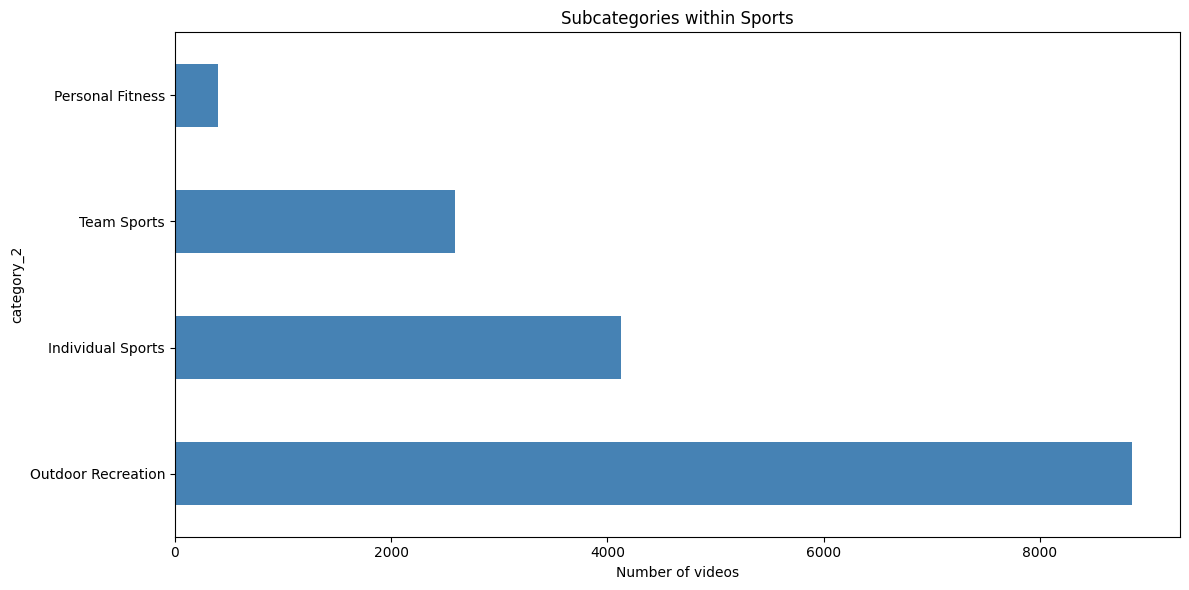

In [32]:
CATEGORY = cfg["data"]["category"]

# Ищем Sports среди category_1 (регистронезависимо)
sports_mask = df_meta["category_1"].str.lower().str.contains("sport", na=False)
df_sports = df_meta[sports_mask].copy()
print(f"Videos in '{CATEGORY}': {len(df_sports):,}")

# Подкатегории (category_2) — это наши целевые классы
print(f"\nSubcategories (category_2) in Sports:")
subcats = df_sports["category_2"].value_counts()
print(subcats)

fig, ax = plt.subplots(figsize=(12, 6))
subcats.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of videos")
ax.set_title(f"Subcategories within {CATEGORY}")
plt.tight_layout()
plt.show()

In [33]:
# Фильтруем подкатегории с достаточным количеством видео
MIN_SAMPLES = cfg["data"]["min_samples_per_class"]
valid_subcats = subcats[subcats >= MIN_SAMPLES].index.tolist()
df_sports = df_sports[df_sports["category_2"].isin(valid_subcats)].copy()

print(f"Subcategories with >= {MIN_SAMPLES} videos: {len(valid_subcats)}")
print(f"Videos after filtering: {len(df_sports):,}")
print(f"\nClasses: {valid_subcats}")

# Кодируем метки
label2id = {label: idx for idx, label in enumerate(sorted(valid_subcats))}
id2label = {idx: label for label, idx in label2id.items()}
df_sports["label"] = df_sports["category_2"].map(label2id)

print(f"\nLabel mapping:")
for label, idx in sorted(label2id.items(), key=lambda x: x[1]):
    count = len(df_sports[df_sports["label"] == idx])
    print(f"  {idx}: {label} ({count:,} videos)")

Subcategories with >= 10 videos: 4
Videos after filtering: 15,976

Classes: ['Outdoor Recreation', 'Individual Sports', 'Team Sports', 'Personal Fitness']

Label mapping:
  0: Individual Sports (4,131 videos)
  1: Outdoor Recreation (8,853 videos)
  2: Personal Fitness (397 videos)
  3: Team Sports (2,595 videos)


In [34]:
df_sports["video_id"]

1086       jMefeL-qX-M
1087       PLdcP55e2bY
1088       Ohv6R87Q-gk
1089       NkolT_879ZA
1090       T6inDvsbLw4
              ...     
1237881    bQ0OhGIVqa0
1237882    c_ma_CTviHc
1238690    qocwYMce6ks
1238691    CSTqceGuOE0
1238730    gXKIgSkbQaw
Name: video_id, Length: 15976, dtype: object

## 1.3 Загрузка субтитров (ASR-транскрибации)

HowTo100M предоставляет субтитры в формате JSON: `{video_id: {"text": [...], "start": [...], "end": [...]}}`.

Файл большой (~6 GB), поэтому мы:
1. Скачиваем его один раз
2. Извлекаем только Sports video_ids
3. Сохраняем отфильтрованное подмножество

In [35]:
CAPTIONS_URL = "https://www.rocq.inria.fr/cluster-willow/amiech/howto100m/caption_howto100m_with_timecode.json"
CAPTIONS_PATH = DATA_DIR / "caption_clean.json"
SPORTS_CAPTIONS_PATH = DATA_DIR / "sports_captions.json"

In [36]:
# Субтитры — самый большой файл. Есть два варианта:
# 1) Скачать полный JSON (~6 GB) с сайта HowTo100M
# 2) Использовать готовый отфильтрованный файл (если уже подготовлен)
import ijson

sports_video_ids = set(df_sports["video_id"].astype(str).values)

def filter_sports_captions(input_path, output_path, sports_ids_set):
    """
    Фильтрует большой JSON-словарь по ключам (video_id) и сохраняет только нужные.
    """
    matched_count = 0
    total_count = 0
    
    # Открываем входной файл в бинарном режиме для ijson
    # Выходной файл - в текстовом, чтобы писать JSONL (JSON Lines)
    with open(input_path, 'rb') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:
        
        # ijson.kvitems возвращает генератор (ключ, значение)
        # Пустая строка '' означает корневой уровень объекта
        try:
            for video_id, captions_data in ijson.kvitems(fin, ''):
                total_count += 1
                
                # video_id из ijson уже строка
                if video_id in sports_ids_set:
                    # Формируем объект для записи
                    # Важно: преобразуем Decimal в float, если нужно, 
                    # так как json.dumps не умеет сериализовать Decimal по умолчанию
                    # Но лучше использовать default=str или кастомный энкодер
                    record = {
                        "video_id": video_id,
                        "start": captions_data["start"],
                        "end": captions_data["end"],
                        "text": captions_data["text"]
                    }
                    # Записываем как одну строку JSON (формат JSONL)
                    # ensure_ascii=False для поддержки русских символов, если есть
                    # default=str поможет с Decimal, превратив их в строки "3.9"
                    fout.write(json.dumps(record, ensure_ascii=False, default=str) + '\n')
                    
                    matched_count += 1
                    
                    if matched_count % 100 == 0:
                        print(f"Найдено {matched_count} спортивных видео. Всего обработано: {total_count}")
                        
        except Exception as e:
            print(f"Ошибка при обработке: {e}")
            
    print(f"Готово. Обработано всего: {total_count}, Найдено спортивных: {matched_count}")

filter_sports_captions(CAPTIONS_PATH, SPORTS_CAPTIONS_PATH, sports_video_ids)
 


Найдено 100 спортивных видео. Всего обработано: 43587
Найдено 200 спортивных видео. Всего обработано: 75835
Найдено 300 спортивных видео. Всего обработано: 114895
Найдено 400 спортивных видео. Всего обработано: 117711
Найдено 500 спортивных видео. Всего обработано: 142859
Найдено 600 спортивных видео. Всего обработано: 151999
Найдено 700 спортивных видео. Всего обработано: 183764
Найдено 800 спортивных видео. Всего обработано: 208898
Найдено 900 спортивных видео. Всего обработано: 245757
Найдено 1000 спортивных видео. Всего обработано: 247198
Найдено 1100 спортивных видео. Всего обработано: 254982
Найдено 1200 спортивных видео. Всего обработано: 255683
Найдено 1300 спортивных видео. Всего обработано: 256395
Найдено 1400 спортивных видео. Всего обработано: 256495
Найдено 1500 спортивных видео. Всего обработано: 273336
Найдено 1600 спортивных видео. Всего обработано: 273436
Найдено 1700 спортивных видео. Всего обработано: 282208
Найдено 1800 спортивных видео. Всего обработано: 310481
Най

In [37]:
import os

print(f"Путь к файлу: {SPORTS_CAPTIONS_PATH}")
print(f"Файл существует: {os.path.exists(SPORTS_CAPTIONS_PATH)}")
print(f"Размер файла: {os.path.getsize(SPORTS_CAPTIONS_PATH) / 1024:.2f} KB")

# Точный подсчёт строк через OS
with open(SPORTS_CAPTIONS_PATH, 'rb') as f:
    line_count = sum(1 for _ in f)
print(f"Строк в файле (binary mode): {line_count}")

Путь к файлу: ..\data\sports_captions.json
Файл существует: True
Размер файла: 99277.19 KB
Строк в файле (binary mode): 15976


In [38]:
import pandas as pd

# Загрузка данных
# lines=True указывает, что это формат JSONL (JSON Lines)
try:
    df_captions = pd.read_json(SPORTS_CAPTIONS_PATH, lines=True)
    print(f"Загружено записей: {len(df_captions)}")
    
    # Просмотр первых строк
    if not df_captions.empty:
        print(df_captions.head())
        
        # Если нужно убедиться, что нет пустых строк (аналог if line.strip()):
        # Pandas обычно сам обрабатывает пустые строки при read_json, 
        # но если есть явные null-значения, их можно удалить:
        # df_captions.dropna(inplace=True)

except Exception as e:
    print(f"Ошибка при загрузке файла: {e}")

Загружено записей: 15976
      video_id                                              start  \
0  jMefeL-qX-M  [3.9, 7.3, 8.88, 11.83, 13.2, 15.36, 17.8, 19....   
1  PLdcP55e2bY  [0.0, 3.89, 6.72, 11.25, 18.96, 22.43, 26.43, ...   
2  Ohv6R87Q-gk  [6.29, 8.46, 10.41, 13.2, 14.91, 17.19, 19.17,...   
3  NkolT_879ZA  [0.23, 3.3, 5.52, 6.5600000000000005, 9.33, 11...   
4  T6inDvsbLw4  [5.28, 8.49, 11.2, 13.95, 16.24, 20.14, 22.36,...   

                                                 end  \
0  [8.88, 11.83, 13.2, 15.36, 17.8, 19.06, 25.24,...   
1  [6.72, 11.25, 18.96, 22.43, 26.43, 28.23, 32.0...   
2  [10.41, 13.2, 14.91, 17.19, 19.17, 21.35, 23.1...   
3  [5.52, 6.5600000000000005, 9.33, 11.91, 15.12,...   
4  [11.2, 13.95, 16.24, 20.14, 22.36, 24.88, 26.9...   

                                                text  
0  [hi harrison kevin, set, slackline, set, slack...  
1  [slackline, learning walk walk walk, walk lay ...  
2  [play line makes slacklining, accessible peopl...  
3  

In [39]:
print(df_captions["video_id"].head())

0    jMefeL-qX-M
1    PLdcP55e2bY
2    Ohv6R87Q-gk
3    NkolT_879ZA
4    T6inDvsbLw4
Name: video_id, dtype: object


## 1.4 Объединение субтитров с метаданными

In [40]:
print(df_captions['text'].fillna('').str.strip().ne('').sum())


15976


In [41]:
# Объединяем все фрагменты субтитров каждого видео в один текст
# и сегментируем на "чанки" для Transformer (каждый чанк — отдельный элемент последовательности)

from tqdm.auto import tqdm
import pandas as pd

# ============================================================
# 🔧 Вспомогательные функции
# ============================================================

def extract_caption_text(caption_data):
    """
    Объединяет все фрагменты субтитров видео в один текст.
    
    Args:
        caption_data: dict с ключами 'text', 'start', 'end' или list текстов
        
    Returns:
        str: объединённый текст
    """
    if caption_data is None:
        return ""
    
    if isinstance(caption_data, dict) and "text" in caption_data:
        texts = caption_data["text"]
    elif isinstance(caption_data, list):
        texts = caption_data
    else:
        return ""
    
    # Фильтруем пустые значения и объединяем
    cleaned = [str(t).strip() for t in texts if pd.notna(t) and str(t).strip()]
    return " ".join(cleaned)


def chunk_caption(caption_data, chunk_size=5):
    """
    Разбивает субтитры на чанки по chunk_size фрагментов.
    Каждый чанк будет отдельным элементом последовательности для Transformer.
    
    Args:
        caption_data: dict с ключом 'text' или list текстов
        chunk_size: количество фрагментов в одном чанке
        
    Returns:
        list[str]: список чанков
    """
    if caption_data is None:
        return []
    
    if isinstance(caption_data, dict) and "text" in caption_data:
        texts = caption_data["text"]
    elif isinstance(caption_data, list):
        texts = caption_data
    else:
        return []
    
    # Предобработка: убираем пустые и NaN
    texts = [str(t).strip() for t in texts if pd.notna(t) and str(t).strip()]
    
    chunks = []
    for i in range(0, len(texts), chunk_size):
        chunk = " ".join(texts[i:i+chunk_size])
        if chunk:  # добавляем только непустые чанки
            chunks.append(chunk)
    return chunks


# ============================================================
# 🔄 Подготовка словаря субтитров для быстрого доступа
# ============================================================

print("🔄 Создаём индекс для быстрого поиска субтитров...")

# Преобразуем DataFrame в словарь: video_id -> данные субтитров
# Используем astype(str) для гарантии совпадения типов ключей
captions_dict = (
    df_captions
    .set_index("video_id")
    .to_dict(orient="index")
)
# Создаём set для O(1) проверки наличия video_id
valid_caption_ids = set(captions_dict.keys())

print(f"✅ Загружено субтитров для {len(captions_dict):,} видео")


# ============================================================
# 🔄 Основной цикл: объединение метаданных и субтитров
# ============================================================

MIN_CAPTION_LENGTH = cfg["data"].get("min_caption_length", 50)
CHUNK_SIZE = cfg["data"].get("chunk_size", 5)

records = []
missing_count = 0
skipped_short_count = 0

print(f"🔄 Обрабатываем {len(df_sports):,} видео (chunk_size={CHUNK_SIZE}, min_length={MIN_CAPTION_LENGTH})...")

for _, row in tqdm(df_sports.iterrows(), total=len(df_sports), desc="Processing videos"):
    vid = str(row["video_id"])  # гарантируем строковый тип для сравнения
    
    # Проверка: есть ли субтитры для этого видео
    if vid not in valid_caption_ids:
        missing_count += 1
        continue
    
    # Извлекаем данные субтитров
    caption_data = captions_dict[vid]
    
    # Объединяем текст
    full_text = extract_caption_text(caption_data)
    
    # Пропускаем видео со слишком короткими субтитрами
    if len(full_text) < MIN_CAPTION_LENGTH:
        skipped_short_count += 1
        continue
    
    # Создаём чанки
    chunks = chunk_caption(caption_data, chunk_size=CHUNK_SIZE)
    
    # Формируем запись
    records.append({
        "video_id": vid,
        "category_2": row["category_2"],
        "label": row["label"],
        "full_text": full_text,
        "chunks": chunks,
        "num_chunks": len(chunks),
        "text_len": len(full_text),  # предвычисляем для удобства EDA
    })

# ============================================================
# 📊 Итоговая статистика
# ============================================================

df_final = pd.DataFrame(records)

print(f"\n{'='*60}")
print(f"📊 РЕЗУЛЬТАТЫ ОБЪЕДИНЕНИЯ ДАННЫХ")
print(f"{'='*60}")
print(f"✅ Видео с субтитрами:      {len(df_final):,}")
print(f"❌ Видео без субтитров:     {missing_count:,} ({missing_count/len(df_sports)*100:.2f}%)")
print(f"⏭️  Пропущено (короткие):    {skipped_short_count:,}")
print(f"📈 Итого обработано:        {len(df_final) + missing_count + skipped_short_count:,} / {len(df_sports):,}")

if not df_final.empty:
    print(f"\n📋 Распределение по классам:")
    print(df_final["category_2"].value_counts().to_string())
    
    print(f"\n📏 Статистика длины текста:")
    print(df_final["text_len"].describe().apply(lambda x: f"{x:,.0f}" if isinstance(x, (int, float)) else x))
    
    print(f"\n🧩 Статистика количества чанков:")
    print(df_final["num_chunks"].describe().apply(lambda x: f"{x:.2f}" if isinstance(x, float) else f"{x:,}"))
else:
    print("⚠️  WARNING: df_final пуст! Проверьте фильтрацию и пути к данным.")

# ============================================================
# 🔍 Быстрая проверка качества
# ============================================================

print(f"\n🔍 Примеры данных (первые 3 видео):")
for idx, row in df_final.head(3).iterrows():
    print(f"\n--- Video: {row['video_id']} | Class: {row['category_2']} ---")
    print(f"Длина текста: {row['text_len']} симв., чанков: {row['num_chunks']}")
    print(f"Текст (первые 200 симв.): {row['full_text'][:200]}...")
    print(f"Первый чанк: {row['chunks'][1]}...")

🔄 Создаём индекс для быстрого поиска субтитров...
✅ Загружено субтитров для 15,976 видео
🔄 Обрабатываем 15,976 видео (chunk_size=3, min_length=10)...


Processing videos: 100%|██████████| 15976/15976 [00:04<00:00, 3619.39it/s]


📊 РЕЗУЛЬТАТЫ ОБЪЕДИНЕНИЯ ДАННЫХ
✅ Видео с субтитрами:      15,976
❌ Видео без субтитров:     0 (0.00%)
⏭️  Пропущено (короткие):    0
📈 Итого обработано:        15,976 / 15,976

📋 Распределение по классам:
category_2
Outdoor Recreation    8853
Individual Sports     4131
Team Sports           2595
Personal Fitness       397

📏 Статистика длины текста:
count    15,976
mean      3,509
std       3,406
min         149
25%       1,209
50%       2,380
75%       4,660
max      33,149
Name: text_len, dtype: object

🧩 Статистика количества чанков:
count    15976.00
mean        41.32
std         36.46
min          1.00
25%         16.00
50%         30.00
75%         55.00
max        341.00
Name: num_chunks, dtype: object

🔍 Примеры данных (первые 3 видео):

--- Video: jMefeL-qX-M | Class: Individual Sports ---
Длина текста: 1242 симв., чанков: 27
Текст (первые 200 симв.): hi harrison kevin set slackline set slack line safely enjoy sport equipment set slack line 3 oval carabiners repel ring wrap 

## 1.5 EDA

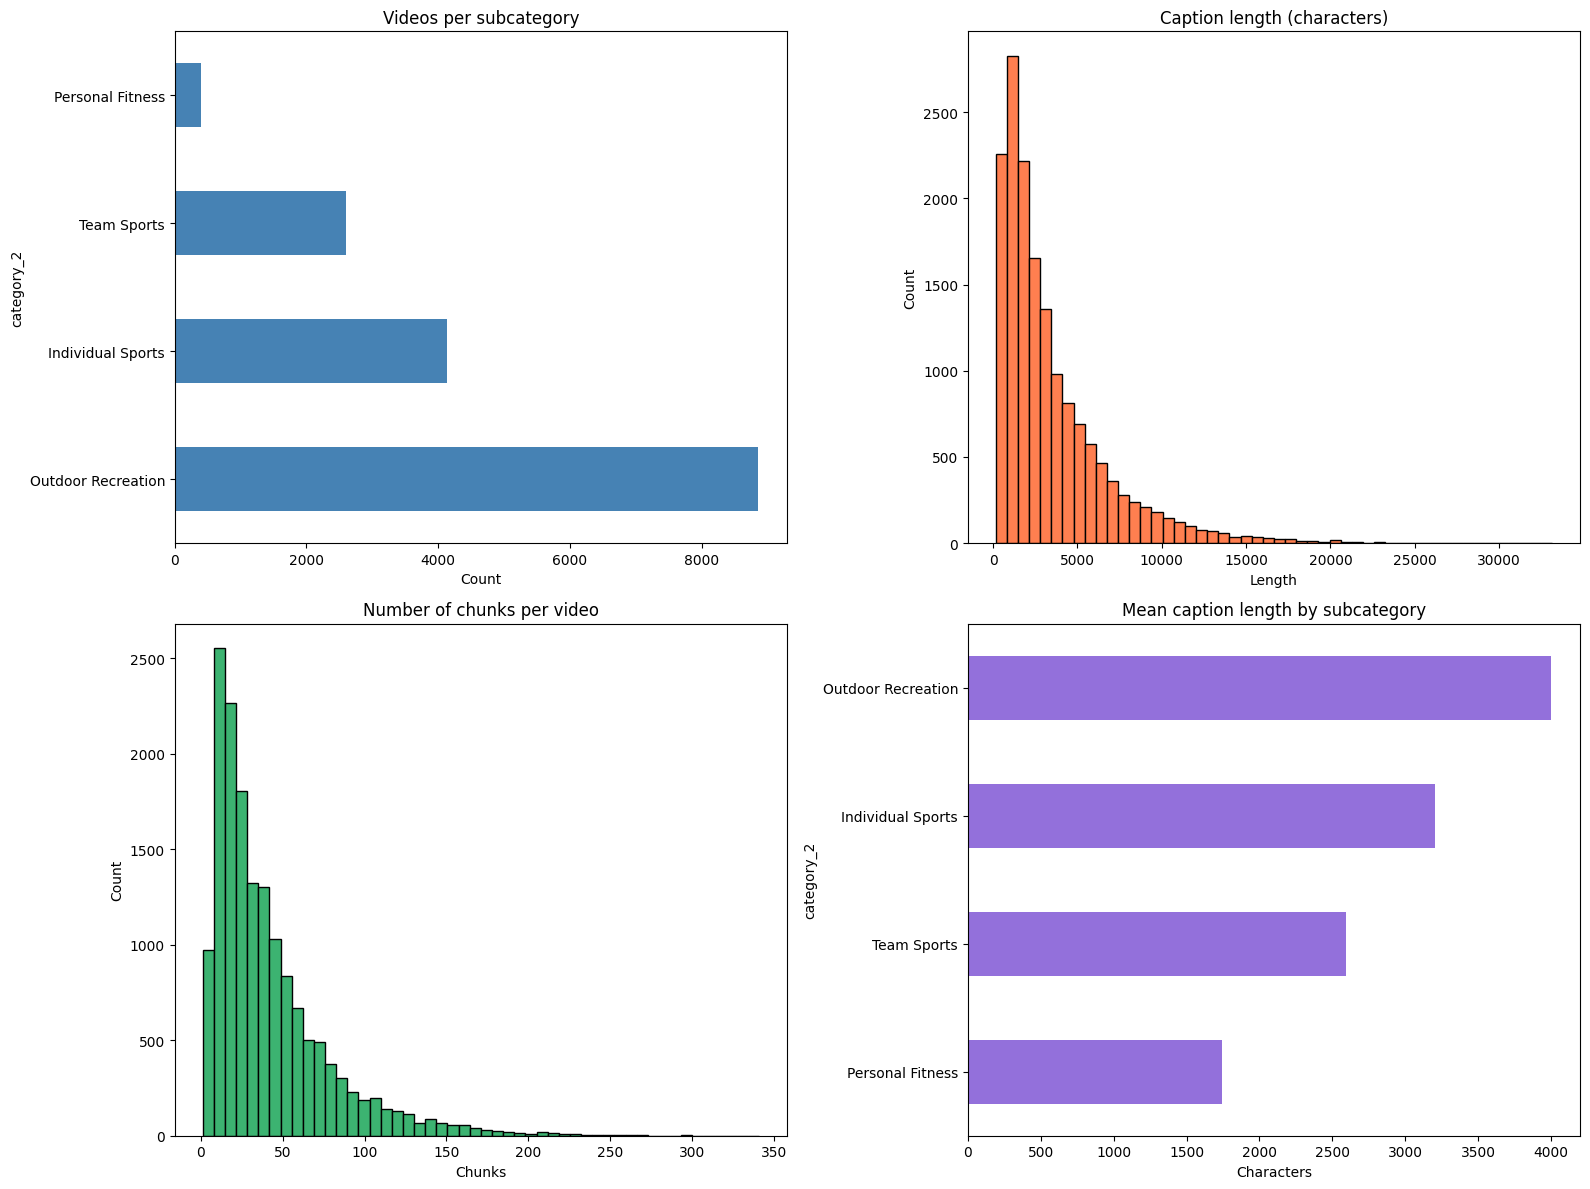


Caption length stats:
count    15976.000000
mean      3508.886017
std       3406.252174
min        149.000000
25%       1209.000000
50%       2380.500000
75%       4660.000000
max      33149.000000
Name: text_len, dtype: float64

Chunks per video stats:
count    15976.000000
mean        41.321858
std         36.462736
min          1.000000
25%         16.000000
50%         30.000000
75%         55.000000
max        341.000000
Name: num_chunks, dtype: float64


In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение по классам
df_final["category_2"].value_counts().plot(kind="barh", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Videos per subcategory")
axes[0, 0].set_xlabel("Count")

# 2. Длина текста (символы)
df_final["text_len"] = df_final["full_text"].str.len()
axes[0, 1].hist(df_final["text_len"], bins=50, color="coral", edgecolor="black")
axes[0, 1].set_title("Caption length (characters)")
axes[0, 1].set_xlabel("Length")
axes[0, 1].set_ylabel("Count")

# 3. Количество чанков на видео
axes[1, 0].hist(df_final["num_chunks"], bins=50, color="mediumseagreen", edgecolor="black")
axes[1, 0].set_title("Number of chunks per video")
axes[1, 0].set_xlabel("Chunks")
axes[1, 0].set_ylabel("Count")

# 4. Средняя длина текста по классам
avg_len = df_final.groupby("category_2")["text_len"].mean().sort_values()
avg_len.plot(kind="barh", ax=axes[1, 1], color="mediumpurple")
axes[1, 1].set_title("Mean caption length by subcategory")
axes[1, 1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

print(f"\nCaption length stats:")
print(df_final["text_len"].describe())
print(f"\nChunks per video stats:")
print(df_final["num_chunks"].describe())

In [43]:
# Примеры текстов из каждой подкатегории
for cat in df_final["category_2"].unique()[:5]:
    sample = df_final[df_final["category_2"] == cat].iloc[0]
    print(f"\n{'='*60}")
    print(f"Category: {cat}")
    print(f"Text (first 300 chars): {sample['full_text'][:300]}...")


Category: Individual Sports
Text (first 300 chars): hi harrison kevin set slackline set slack line safely enjoy sport equipment set slack line 3 oval carabiners repel ring wrap ring pieces webbing fit trees end having overhand knot bite tie knots link line slacklining end tie overhand knot bite important protect trees slackline use towels cardboard p...

Category: Team Sports
Text (first 300 chars): kids coaches coach kip murphy talk bat flips proper way badass what's accidentally bat flip blowing hard went rows deep hit lands mom face she's key go fix lasagna tell dummy eat cheese dogs slap daughter's titties important thing good bat flip people think homerun duh wrong bat flip bat go break fu...

Category: Outdoor Recreation
Text (first 300 chars): elijah build shelter watch frame trees straight tree comes into splits into comes straight splits into y get long pole steady hang weight strong stack sticks coming way way banks away wind lucky heart make frame tarp shelter 18 frame shel

## 1.6 Train / Val / Test split

In [44]:
from sklearn.model_selection import train_test_split

SEED = cfg["data"]["random_seed"]
TEST_SIZE = cfg["data"]["test_size"]
VAL_SIZE = cfg["data"]["val_size"]

# Стратифицированный split: train / temp → temp / val / test
df_train, df_temp = train_test_split(
    df_final, test_size=TEST_SIZE + VAL_SIZE, random_state=SEED, stratify=df_final["label"]
)
relative_val = VAL_SIZE / (TEST_SIZE + VAL_SIZE)
df_val, df_test = train_test_split(
    df_temp, test_size=1 - relative_val, random_state=SEED, stratify=df_temp["label"]
)

print(f"Train: {len(df_train):,}")
print(f"Val:   {len(df_val):,}")
print(f"Test:  {len(df_test):,}")
print(f"Total: {len(df_train) + len(df_val) + len(df_test):,}")

# Проверка стратификации
print("\nClass distribution (%):")
for split_name, split_df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    dist = split_df["category_2"].value_counts(normalize=True).round(3)
    print(f"\n{split_name}:")
    print(dist)

Train: 11,183
Val:   2,396
Test:  2,397
Total: 15,976

Class distribution (%):

Train:
category_2
Outdoor Recreation    0.554
Individual Sports     0.259
Team Sports           0.162
Personal Fitness      0.025
Name: proportion, dtype: float64

Val:
category_2
Outdoor Recreation    0.554
Individual Sports     0.258
Team Sports           0.162
Personal Fitness      0.025
Name: proportion, dtype: float64

Test:
category_2
Outdoor Recreation    0.554
Individual Sports     0.259
Team Sports           0.163
Personal Fitness      0.025
Name: proportion, dtype: float64


## 1.7 Сохранение данных

In [47]:
# Сохраняем splits как parquet (эффективнее CSV для строковых данных)
## 1.7 Сохранение данных
LABEL_COL = "category_2"
# === СОХРАНЕНИЕ СПЛИТОВ ===
df_train.to_parquet(DATA_DIR / "train.parquet", index=False)
df_val.to_parquet(DATA_DIR / "val.parquet", index=False)
df_test.to_parquet(DATA_DIR / "test.parquet", index=False)

# === ПОДГОТОВКА МАППИНГОВ ДЛЯ СОХРАНЕНИЯ ===
# Конвертируем в нативные Python-типы для совместимости с JSON
# unique_labels уже отсортированы и содержат инты (из df_videos[LABEL_COL])
unique_labels = sorted(df_final[LABEL_COL].unique().tolist())  # numpy → Python list

# Создаём label2id: {label_int: id_int} с явным приведением типов
label2id_final = {int(label): int(idx) for idx, label in enumerate(unique_labels)}
id2label_final = {int(idx): int(label) for label, idx in label2id_final.items()}

# === СОХРАНЕНИЕ МАППИНГОВ ===
# Ключи в JSON должны быть строками, поэтому конвертируем при сериализации
with open(DATA_DIR / "label2id.json", "w", encoding="utf-8") as f:
    # {str(label): int(id)} для корректного JSON
    json.dump({str(k): v for k, v in label2id_final.items()}, f, indent=2, ensure_ascii=False)

with open(DATA_DIR / "id2label.json", "w", encoding="utf-8") as f:
    # {str(id): int(label)} для корректного JSON
    json.dump({str(k): v for k, v in id2label_final.items()}, f, indent=2, ensure_ascii=False)

# === ЛОГИРОВАНИЕ ===
print("✅ Данные сохранены:")
print(f"  • {DATA_DIR / 'train.parquet'} ({len(df_train):,} строк)")
print(f"  • {DATA_DIR / 'val.parquet'} ({len(df_val):,} строк)")
print(f"  • {DATA_DIR / 'test.parquet'} ({len(df_test):,} строк)")
print(f"  • {DATA_DIR / 'label2id.json'}")
print(f"  • {DATA_DIR / 'id2label.json'}")
print(f"\n📊 Количество классов: {len(label2id_final)}")
print(f"🔑 Пример label2id: {dict(list(label2id_final.items())[:3])}")
print("🎉 Data preparation complete!")

ValueError: invalid literal for int() with base 10: 'Individual Sports'